# 1. Set up

In [2]:
!pip install pandas
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install xgboost category_encoders scikit-plot
!pip install pyproj
!pip install seaborn
!pip install graphviz

# 2. Import necessary libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV

import torch.nn as nn

import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,confusion_matrix, classification_report, precision_recall_curve, auc, recall_score, precision_score,
    f1_score
)
from pyproj import Transformer
import shap
from tqdm import tqdm
import xgboost as xgb

from utils import *

c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Define global variables

we will be using march as the training month and april as the validation month

In [4]:
# INPUT_X_PATH = "../data/output_data/data_training_june.csv"
# INPUT_X_EVAL_PATH = "../data/output_data/data_validation_august.csv"
# INPUT_Y_EVAL_PATH = "../data/output_data/data_validation_august_y.csv"
# INPUT_Y_PATH = "../data/output_data/data_training_june_y.csv"

# INPUT_FINAL_DF_PATH  = "../data/output_data/final_df_non_supervised_june.csv"
# INPUT_FINAL_DF_EVAL_PATH  = "../data/output_data/final_df_eval_non_supervised_june.csv"


INPUT_X_PATH = "../data/output_data/data_training_june.csv"
INPUT_X_EVAL_PATH = "../data/output_data/data_validation_test.csv"
# INPUT_Y_EVAL_PATH = "../data/output_data/data_validation_august_y.csv"
INPUT_Y_PATH = "../data/output_data/data_training_june_y.csv"


INPUT_FINAL_DF_PATH  = "../data/output_data/final_df_non_supervised_sept.csv"
INPUT_FINAL_DF_EVAL_PATH  = "../data/output_data/final_df_eval_non_supervised_sept.csv"

In [5]:
OUTPUT_FEATURE_IMPORTANCE_XGB = "../powerbi/feature_importance_xgb_sept.csv"

In [6]:
train_losses = list()
target_col = "target"

Let's define some colors for the viz we will be doing

In [7]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

# 4. Functions

# 5. Code

## 5.1. Data loading

We will load the data, both the training and the validation data

In [8]:
X = pd.read_csv(INPUT_X_PATH, sep=";")
y = pd.read_csv(INPUT_Y_PATH, sep=";")[target_col]
X_eval = pd.read_csv(INPUT_X_EVAL_PATH, sep=";")
# y_eval = pd.read_csv(INPUT_Y_EVAL_PATH, sep=";")[target_col]

final_df = pd.read_csv(INPUT_FINAL_DF_PATH, sep=";")
final_df_eval = pd.read_csv(INPUT_FINAL_DF_EVAL_PATH, sep=";")

In [9]:
X.head(5)

,porcentaje_calidad_datos_trimestre_actual_incorrectos,consumo_zero_anio_anterior,consumo_zero_anio_actual,porcentaje_calidad_datos_anio_actual_incorrectos,consumo_zero_mes_anio_pasado,consumo_zero_mes_actual,consumo_zero_trimestre_anio_pasado,consumo_min_anio_actual,consumo_min_anio_anterior,consumo_zero_trimestre_actual,...,cnt_eventos_anio_pasado_2_6,cnt_eventos_semana_actual_4_8,cnt_eventos_anio_actual_4_5,consumo_umbral_trimestre_actual,cnt_eventos_trimestre_pasado_2_14,consumo_umbral_mes_pasado,cnt_eventos_misma_semana_anio_pasado_6_NA,cnt_eventos_semana_actual_1_48,cnt_eventos_anio_pasado_4_7,consumo_umbral_semana_pasada
0,0.09,0.0,0.0,0.06,0.0,0.0,0.0,30.0,2.0,0.0,...,0.0,0.0,0.0,2028.0,0.0,690.0,20.0,0.0,0.0,167.0
1,0.50,0.0,0.0,0.24,0.0,0.0,0.0,116.0,129.0,0.0,...,1.0,0.0,4.0,2158.0,3.0,741.0,32.0,0.0,0.0,167.0
2,0.18,0.0,0.0,0.07,0.0,0.0,0.0,197.0,0.0,0.0,...,0.0,0.0,0.0,2170.0,0.0,744.0,0.0,0.0,0.0,168.0
3,0.09,0.0,0.0,0.02,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,292.0,0.0,110.0,20.0,0.0,0.0,2.0
4,0.09,0.0,0.0,0.02,0.0,0.0,0.0,853.0,1248.0,0.0,...,0.0,0.0,0.0,2162.0,0.0,744.0,56.0,0.0,7.0,168.0


In [10]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

## 5.2. Supervised learning

In [11]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_eval.fillna(0, inplace=True)
# y_eval.fillna(0, inplace=True) 

### 5.2.1. Modelling

Realizamos un target encoding a aquellas variables que sean categóricas en nuestro dato:

In [12]:
encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X, y)
# X_test_enc = encoder.transform(X_test)

Finalmente definimos el modelo y lo entrenamos

In [13]:
model = xgb.XGBClassifier(
    n_estimators=80,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train_enc, y)


c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### 5.2.2. Metrics extraction

Para poder calcular las métricas, en primer lugar debemos calcular las predicciones

In [14]:
y_proba = model.predict_proba(X_train_enc)[:, 1] 
y_pred = model.predict(X_train_enc)

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [15]:
auc_df = compute_individual_auc(X, y, target_col="target")

print(auc_df.head(15))

Computing AUCs: 100%|██████████| 125/125 [00:00<00:00, 169.89it/s]

                                              feature       auc
0    porcentaje_calidad_datos_anio_actual_incorrectos  0.900534
1   porcentaje_calidad_datos_trimestre_actual_inco...  0.891138
2                            consumo_zero_anio_actual  0.736544
3                          consumo_zero_anio_anterior  0.711898
4                       consumo_zero_trimestre_actual  0.663739
5   porcentaje_calidad_datos_trimestre_actual_corr...  0.642457
6   porcentaje_calidad_datos_mismo_trimestre_anio_...  0.640826
7   porcentaje_calidad_datos_mismo_mes_anio_pasado...  0.637391
8       porcentaje_calidad_datos_mes_pasado_correctos  0.628565
9                       consumo_zero_trimestre_pasado  0.628045
10                 consumo_zero_trimestre_anio_pasado  0.626346
11  porcentaje_calidad_datos_misma_semana_anio_pas...  0.622998
12      porcentaje_calidad_datos_mes_actual_correctos  0.619288
13   porcentaje_calidad_datos_semana_actual_correctos  0.612131
14   porcentaje_calidad_datos_semana_pas

In [16]:
# auc_df = compute_individual_auc(X_eval, y_eval, target_col="target")

# print(auc_df.head(15))

In [17]:
final_df["target"].value_counts(normalize=True)

target
0.0    0.954379
1.0    0.045621
Name: proportion, dtype: float64

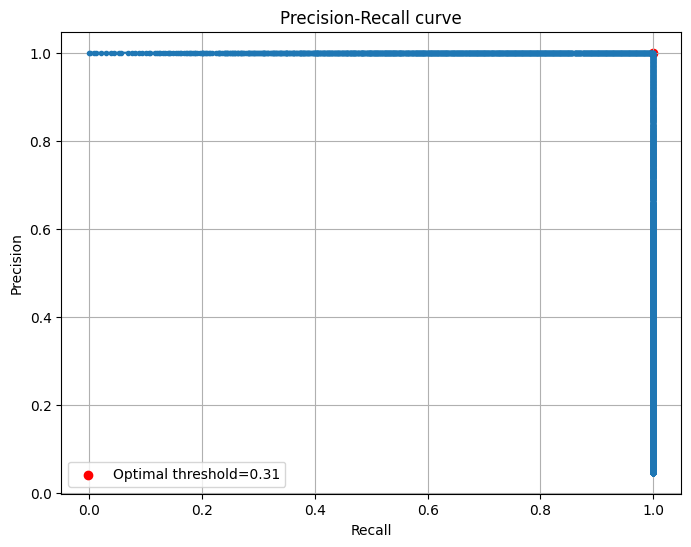

In [18]:
thres_train, _ = find_optimal_thres(y, y_proba)

### 5.2.3. Predictions calibration

In [19]:
calibrated_model = CalibratedClassifierCV(estimator=model,
                                          method="isotonic", cv=5)
calibrated_model.fit(X, y)

proba_cal_val = calibrated_model.predict_proba(X_eval)[:,1]

c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia

In [20]:
# # ejemplo de costes
# C_FN = 1000  # coste de dejar pasar un fraude
# C_FP = 50    # coste de investigar un inocente

# best_cost, best_thr, FN, FP = find_cost_optimal_threshold(y_eval, proba_cal_val, C_FN, C_FP)
# print(f"Umbral coste-óptimo: {best_thr:.3f} (Coste esperado: {best_cost}, FN={FN}, FP={FP})")


In [21]:
def plot_lift(y_true, proba, bins=20):
    df = pd.DataFrame({"y": y_true, "proba": proba})
    df = df.sort_values("proba", ascending=False).reset_index(drop=True)
    df["bucket"] = pd.qcut(df.index, bins, labels=False)

    lift_table = df.groupby("bucket").agg(
        n=("y","size"),
        frauds=("y","sum"),
        avg_score=("proba","mean")
    ).reset_index()

    lift_table["fraud_rate"] = lift_table["frauds"] / lift_table["n"]
    global_rate = df["y"].mean()
    lift_table["lift"] = lift_table["fraud_rate"] / global_rate
    lift_table["cum_frauds"] = lift_table["frauds"].cumsum()
    lift_table["cum_frauds_pct"] = lift_table["cum_frauds"] / df["y"].sum()

    plt.figure(figsize=(8,6))
    plt.plot(np.linspace(0,100,bins), lift_table["cum_frauds_pct"]*100, marker='o')
    plt.xlabel("% población (ordenada por score)")
    plt.ylabel("% fraudes capturados (acumulado)")
    plt.title("Curva Lift acumulada (modelo supervisado)")
    plt.grid(True)
    plt.show()

    return lift_table

# lift_table = lift_chart_plot(y_eval, proba_cal_val, num_chunks=20)


In [22]:
y_pred = (y_proba >= thres_train).astype(int)

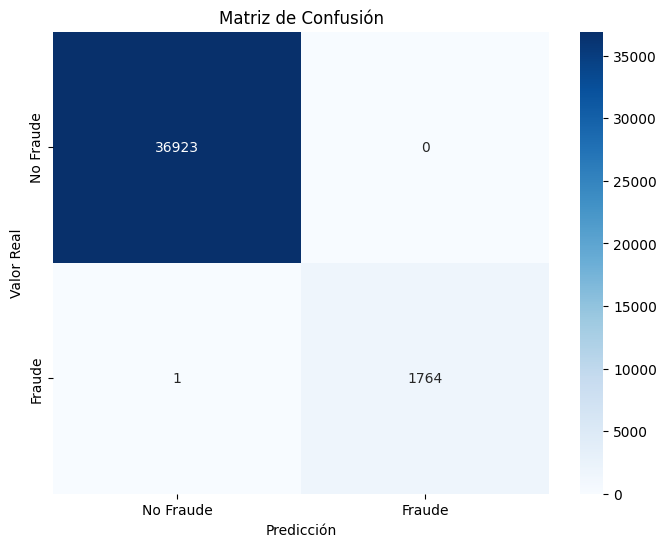


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     36923
         1.0       1.00      1.00      1.00      1765

    accuracy                           1.00     38688
   macro avg       1.00      1.00      1.00     38688
weighted avg       1.00      1.00      1.00     38688



In [23]:
cm = confusion_matrix(y, y_pred)
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
 
# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y, y_pred))

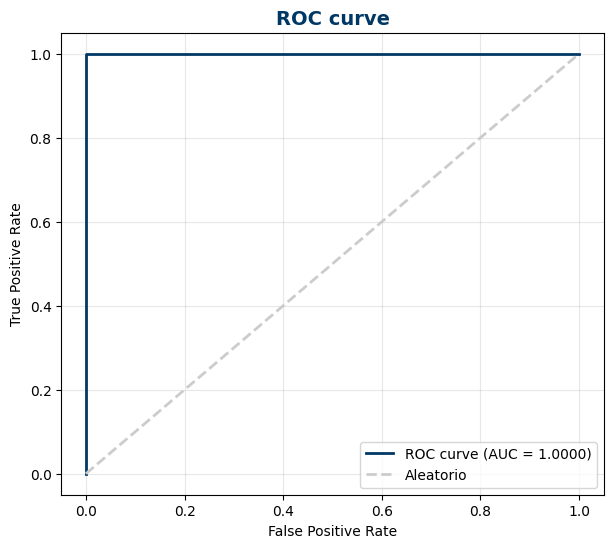

ROC AUC Score: 1.0000


In [24]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

Let's see also gain and lift curves

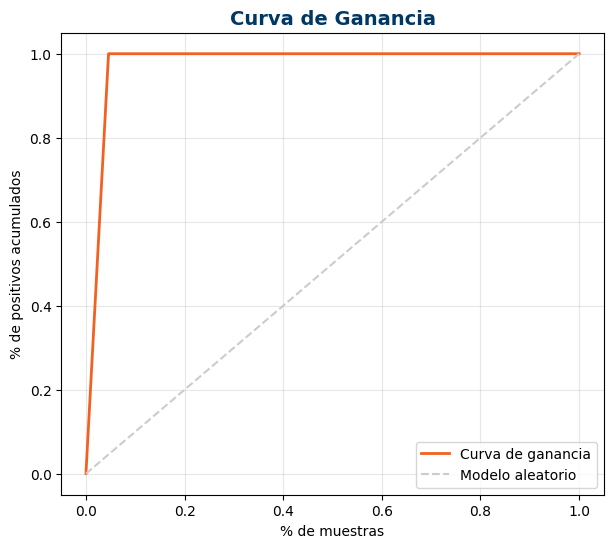

In [25]:
plot_gain(y, y_proba)

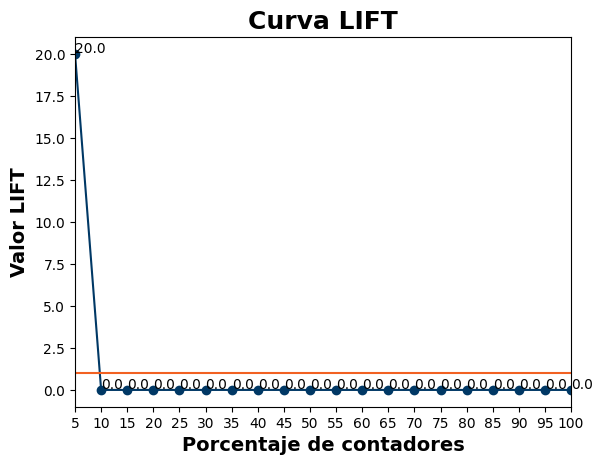

In [26]:
lift_chart_plot(y, y_proba, num_chunks=20)

In [27]:
final_df["target"].value_counts()

target
0.0    36923
1.0     1765
Name: count, dtype: int64

In [28]:
# # First, get the indices of the test set in final_df
# test_indices = X_test.index
# train_indices = X_train.index

# # Assign the predicted probabilities to the correct rows
# final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
# final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

# final_df.loc[test_indices, "train"] = 0
# final_df.loc[train_indices, "train"] = 1

In [29]:
final_df["pred_proba"] = y_proba

In [30]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado"]*0.3 + final_df["pred_proba"]*0.7

We define the cuts attending to the lift chart previously defined:

In [31]:
cuts = [25, 35]  
thresholds = get_probability_thresholds(y, y_proba, cuts)

print("Thresholds:", thresholds)

Thresholds: [0.00010866507363971323, 4.645149238058366e-05]


We create the new cateogria_fraude column used to order the probabilistic results of the fraud

In [32]:
conditions = [
    final_df["final_scoring"] < thresholds[0],                             
    (final_df["final_scoring"] >= thresholds[0]) & (final_df["final_scoring"] < thresholds[1]),  
    final_df["final_scoring"] >= thresholds[1]                             
]

choices = ["Bajo", "Medio", "Alto"]

final_df["categoria_fraude"] = np.select(conditions, choices, default="Bajo")

### 5.4.3. Feature importance

In [33]:
importancias = model.feature_importances_
features = X.columns

df_importancia = pd.DataFrame({
    'feature': features,
    'importance': importancias
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

df_importancia.head(10)

,feature,importance
0,porcentaje_calidad_datos_trimestre_actual_inco...,0.408850
1,porcentaje_calidad_datos_anio_actual_incorrectos,0.137579
2,consumo_zero_anio_actual,0.098131
3,porcentaje_calidad_datos_trimestre_pasado_corr...,0.059453
4,consumo_zero_anio_anterior,0.050041
5,porcentaje_calidad_datos_mes_pasado_incorrectos,0.027198
6,cnt_eventos_anio_pasado_4_7,0.019016
7,porcentaje_calidad_datos_misma_semana_anio_pas...,0.009298
8,cnt_eventos_anio_pasado_4_6,0.008829
9,consumo_max_trimestre_actual,0.008203


Let's save this data frame into the powerbi folder. We will use then this data to show it in the dashboard

In [34]:
df_importancia.head(10).to_csv(OUTPUT_FEATURE_IMPORTANCE_XGB, sep=";", decimal=",")

## 5.3. Evaluating the model

We are going to use the previously trained model to test it in the april data for example. Thus, let's go for it

In [35]:
for col in X:
    if col not in X_eval:
        X_eval[col] = 0

In [36]:
y_proba_eval = model.predict_proba(X_eval[X.columns])[:, 1] 
y_pred_eval = model.predict(X_eval[X.columns]) # threshold 0.5

In [37]:
final_df_eval["pred_proba"] = y_proba_eval
final_df_eval["final_scoring"] = final_df_eval["fraude_score_no_supervisado"]*0.3 + final_df_eval["pred_proba"]*0.7

In [38]:
# thresholds_val = get_probability_thresholds(y_eval, final_df_eval["final_scoring"], cuts)

# conditions_val = [
#     final_df_eval["final_scoring"] < thresholds_val[0],                             
#     (final_df_eval["final_scoring"] >= thresholds_val[0]) & (final_df_eval["final_scoring"] < thresholds_val[1]),  
#     final_df_eval["final_scoring"] >= thresholds_val[1]                             
# ]

# final_df_eval["categoria_fraude"] = np.select(conditions_val, choices, default="Bajo")

In [39]:
# final_df_eval["categoria_fraude"].value_counts()

In [40]:
# thres_val, _ = find_optimal_thres(y_eval, y_proba_eval)

Let's define the prediction array making use of the extracted threshold

In [41]:
# y_pred_eval = (y_proba_eval >= thres_val).astype(int)
y_pred_eval = (y_proba_eval >= thres_train).astype(int)

In [42]:
# thres_val

If we show the confusion matrix:

In [43]:
model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 4,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 80,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'use_label_encoder': False}

In [44]:
# cm = confusion_matrix(y_eval, y_pred_eval)
# # Crear una visualización más clara
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, cmap='Blues',
#             xticklabels=['No Fraude', 'Fraude'],
#             yticklabels=['No Fraude', 'Fraude'], )
# plt.title('Matriz de Confusión')
# plt.xlabel('Predicción')
# plt.ylabel('Valor Real')
# plt.show()
 
# # También puedes mostrar el reporte de clasificación completo
# print("\nReporte de Clasificación:")
# print(classification_report(y_eval, y_pred_eval))

# print(f1_score(y_eval, y_pred_eval))

In [45]:
# cm = confusion_matrix(y_eval, y_pred_eval, normalize="true")
# # Crear una visualización más clara
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, cmap='Blues',
#             xticklabels=['No Fraude', 'Fraude'],
#             yticklabels=['No Fraude', 'Fraude'], )
# plt.title('Matriz de Confusión')
# plt.xlabel('Predicción')
# plt.ylabel('Valor Real')
# plt.show()
 
# # También puedes mostrar el reporte de clasificación completo
# print("\nReporte de Clasificación:")
# print(classification_report(y_eval, y_pred_eval))

# print(f1_score(y_eval, y_pred_eval))

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [46]:
# fpr, tpr, thresholds = roc_curve(y_eval, y_proba_eval)
# roc_auc_eval = roc_auc_score(y_eval, y_proba_eval)

# plt.figure(figsize=(7,6))
# plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc_eval:.4f})")
# plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# # Estilo
# plt.grid(alpha=0.3)
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
# plt.legend(loc="lower right", fontsize=10)
# plt.show()

# print(f"ROC AUC Score: {roc_auc_eval:.4f}")

Mostramos también las curvas de ganancia y lift a continuación

In [47]:
# plot_gain(y_eval, y_proba_eval)

In [48]:
# lift_chart_plot(y_eval, y_proba_eval, num_chunks=20)

In [49]:
# lift_chart_plot(y_eval, y_proba_eval, num_chunks=10)

In [50]:
hundred_cups_fraud = final_df_eval.sort_values(by="pred_proba", ascending=False).head(100)

In [51]:
hundred_cups_fraud["cups_sgc"].values

array(['ES0022000005530270BE1P', 'ES0022000005572984YW1P',
       'ES0022000008452871YJ1P', 'ES0022000009097860NJ1P',
       'ES0022000005566250NF1P', 'ES0022000008775426TQ1P',
       'ES0022000008864743CR1P', 'ES0022000008201658DY1P',
       'ES0022000008097453DZ1P', 'ES0022000008221006EB1P',
       'ES0022000008630903LW1P', 'ES0022000007615147SH1P',
       'ES0022000005528674BJ1P', 'ES0022000008564717QX1P',
       'ES0022000005566858SV1P', 'ES0022000005553649QX1P',
       'ES0022000005494242DN1P', 'ES0022000005559712GR1P',
       'ES0022000005523961JS1P', 'ES0022000008449411VA1P',
       'ES0022000007724366AX1P', 'ES0022000008446935RB1P',
       'ES0022000008232032HC1P', 'ES0022000008360109KX1P',
       'ES0022000005505032HS1P', 'ES0022000005527498YX1P',
       'ES0022000005578498SL1P', 'ES0022000005578990ZM1P',
       'ES0022000008746522DT1P', 'ES0022000008655104JF1P',
       'ES0022000008016244CH1P', 'ES0022000005530683YK1P',
       'ES0022000005552012ZY1P', 'ES0022000005564502MF1P

In [52]:
FIRST_100_CUPS_AITOR_PATH = "../data/inputs/piloto_septiembre_100_cups_aitor.csv"

In [53]:
FIRST_100_CUPS_AITOR_PATH_2 = "../data/inputs/aitor_piloto.csv"

In [54]:
hundred_cups_fraud_aitor = pd.read_csv(FIRST_100_CUPS_AITOR_PATH, sep=",")
hundred_cups_fraud_aitor_2 = pd.read_csv(FIRST_100_CUPS_AITOR_PATH_2, sep=",")

In [55]:
all_cups_fraud_aitor = pd.concat([hundred_cups_fraud_aitor, hundred_cups_fraud_aitor_2]).drop_duplicates()

In [56]:
merged_1 = hundred_cups_fraud.merge(all_cups_fraud_aitor, on="cups_sgc", how="inner", suffixes=('_model', '_aitor'))

In [57]:
merged_1["cups_sgc"].values

array(['ES0022000005530270BE1P', 'ES0022000009097860NJ1P',
       'ES0022000008097453DZ1P', 'ES0022000008630903LW1P',
       'ES0022000008449411VA1P', 'ES0022000008232032HC1P',
       'ES0022000005505032HS1P', 'ES0022000005578990ZM1P',
       'ES0022000008746522DT1P', 'ES0022000008655104JF1P',
       'ES0022000008749067GS1P', 'ES0022000008847767VE1P',
       'ES0022000007872200ZT1P', 'ES0022000008864718HE1P',
       'ES0022000008147770NF1P', 'ES0022000008233577VR1P',
       'ES0022000007035204PC1P', 'ES0022000005497835GV1P',
       'ES0022000008653481BV1P', 'ES0022000005526486PX1P',
       'ES0022000009099680EQ1P', 'ES0022000008768937VJ1P',
       'ES0022000008112974VX1P', 'ES0022000008674850CL1P',
       'ES0022000005499401AL1P'], dtype=object)

## 5.4. Explainability

Let's make a global shap plot, in order to understand how the model gives predictions

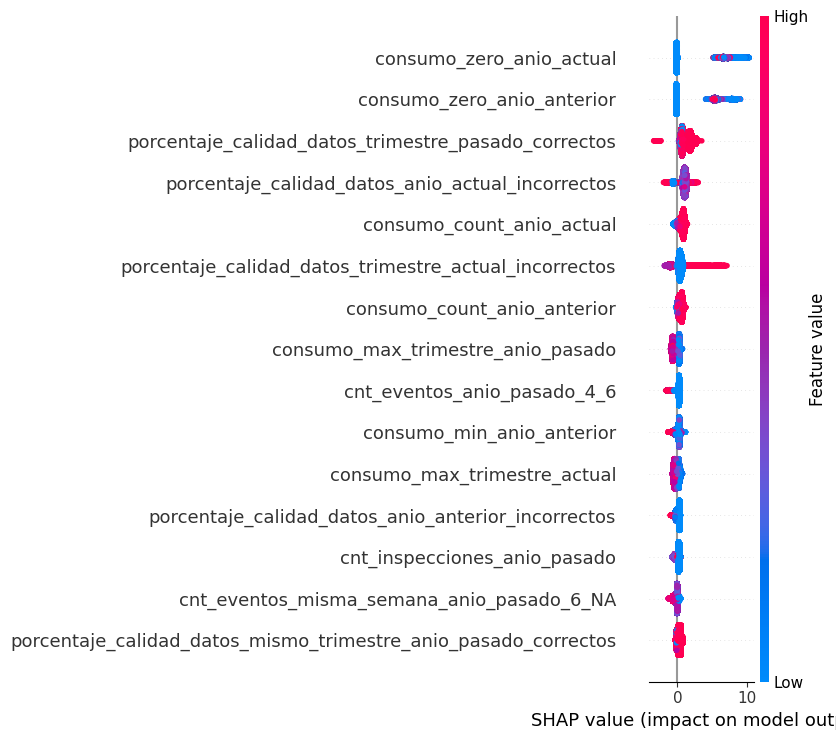

In [58]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_eval)

shap.summary_plot(shap_values, X_eval, max_display=15)

In [59]:
df_shap_eval = final_df_eval[["cups_sgc", "cnt_id"]].join(X_eval, how="right")
df_shap_eval.head(5)

,cups_sgc,cnt_id,porcentaje_calidad_datos_trimestre_actual_incorrectos,consumo_zero_anio_anterior,consumo_zero_anio_actual,porcentaje_calidad_datos_anio_actual_incorrectos,consumo_zero_mes_anio_pasado,consumo_zero_mes_actual,consumo_zero_trimestre_anio_pasado,consumo_min_anio_actual,...,cnt_eventos_anio_pasado_2_6,cnt_eventos_semana_actual_4_8,cnt_eventos_anio_actual_4_5,consumo_umbral_trimestre_actual,cnt_eventos_trimestre_pasado_2_14,consumo_umbral_mes_pasado,cnt_eventos_misma_semana_anio_pasado_6_NA,cnt_eventos_semana_actual_1_48,cnt_eventos_anio_pasado_4_7,consumo_umbral_semana_pasada
0,ES0022000001000050VC1P,SAG0185746545,0.0,0.0,0.0,0.25,0.0,0.0,0.0,124.0,...,0.0,0.0,0.0,2041.0,0.0,744.0,24.0,0.0,0.0,168.0
1,ES0022000001000051VK1P,ZIV0048682250,0.0,1949.0,6816.0,0.23,72.0,24.0,1008.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ES0022000001000052VE1P,ZIV0048682245,0.0,0.0,23.0,0.18,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1924.0,0.0,721.0,0.0,0.0,0.0,146.0
3,ES0022000001000070HV1P,SAG0185746689,0.0,0.0,7.0,0.21,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1925.0,0.0,739.0,50.0,0.0,0.0,139.0
4,ES0022000001000071HH1P,ZIV0048687588,0.0,1135.0,1236.0,0.16,97.0,117.0,353.0,0.0,...,0.0,0.0,0.0,549.0,0.0,241.0,38.0,0.0,0.0,47.0


In [60]:
# Pasamos shap_values a DataFrame
df_shap_local = pd.DataFrame(shap_values, columns=X_eval.columns)

# Añadimos las predicciones y el identificador
df_local_explain = pd.DataFrame({
    "cups_sgc": df_shap_eval["cups_sgc"], 
    "cnt_id": df_shap_eval["cnt_id"], 
    "prediction": model.predict_proba(X_eval)[:,1]
})

# 3. Pasamos a formato largo (para Power BI)
df_shap_long = df_shap_local.reset_index().melt(
    id_vars="index",
    var_name="feature",
    value_name="shap_value"
)

# 4. Unimos con los identificadores y predicciones
df_explain_final = df_shap_long.merge(
    df_local_explain.reset_index(),
    on="index"
).drop(columns=["index"])

df_explain_final["abs_shap_value"] = df_explain_final["shap_value"].abs()
# Esto lo exportas a CSV y lo cargas en Power BI
df_explain_final.to_csv("../powerbi/shap_local_explain_xgb.csv", index=False, decimal=",", sep=";")


In [61]:
some_cups = df_explain_final[df_explain_final["cups_sgc"].isin(["ES0022000008907273YG1P", "ES0022000005510110DX1P", "ES0022000005511050GF1P", "ES0022000005541296PP1P", "ES0022000005576634AH1P", "ES0022000008112974VX1P", "ES0022000008435084SM1P", "ES0022000008612773NL1P", "ES0022000008625444BV1P", "ES0022000008907273YG1P", "ES0022000009106472LT1P"])].sort_values(["cups_sgc", "abs_shap_value"], ascending = False)#.to_csv("../powerbi/shap_local_explain_xgb_some_cups.csv", index=False, decimal=",", sep=";")


In [62]:
some_cups

,feature,shap_value,cups_sgc,cnt_id,prediction,abs_shap_value
597444,consumo_zero_anio_actual,6.430852,ES0022000009106472LT1P,ZIV0044114711,0.999999,6.430852
397961,consumo_zero_anio_anterior,5.068484,ES0022000009106472LT1P,ZIV0044114711,0.999999,5.068484
2392791,porcentaje_calidad_datos_trimestre_pasado_corr...,1.734202,ES0022000009106472LT1P,ZIV0044114711,0.999999,1.734202
796927,porcentaje_calidad_datos_anio_actual_incorrectos,0.984722,ES0022000009106472LT1P,ZIV0044114711,0.999999,0.984722
198478,porcentaje_calidad_datos_trimestre_actual_inco...,-0.709628,ES0022000009106472LT1P,ZIV0044114711,0.999999,0.709628
...,...,...,...,...,...,...
22163522,cnt_eventos_semana_actual_2_3,0.000000,ES0022000005510110DX1P,ZIV0048325754,0.999999,0.000000
22761971,cnt_eventos_mes_actual_2_14,0.000000,ES0022000005510110DX1P,ZIV0048325754,0.999999,0.000000
23160937,cnt_eventos_semana_actual_4_8,0.000000,ES0022000005510110DX1P,ZIV0048325754,0.999999,0.000000
23759386,cnt_eventos_trimestre_pasado_2_14,0.000000,ES0022000005510110DX1P,ZIV0048325754,0.999999,0.000000


## 1. Visualización de Árboles Individuales
### XGBoost permite visualizar árboles específicos del ensemble:

c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

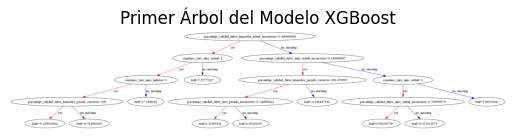

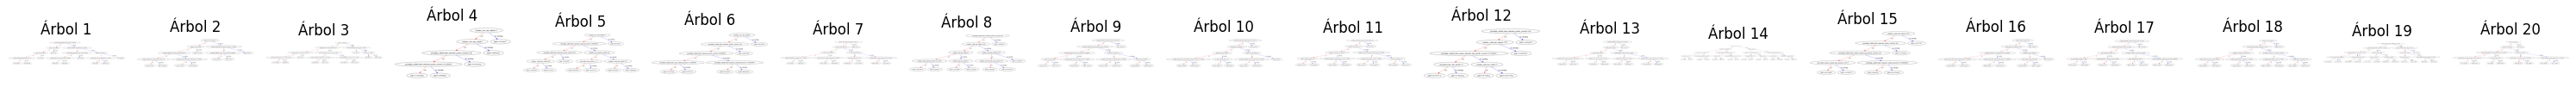

In [63]:
import matplotlib.pyplot as plt
from xgboost import plot_tree
import graphviz



# Visualizar el primer árbol del modelo
plt.figure(figsize=(20, 10))
plot_tree(model, num_trees=0, rankdir='TB')
plt.title("Primer Árbol del Modelo XGBoost")
plt.show()



# Visualizar múltiples árboles (primeros 20)
fig, axes = plt.subplots(1, 20, figsize=(30, 10))
for i in range(20):
    plot_tree(model, num_trees=i, ax=axes[i])
    axes[i].set_title(f"Árbol {i+1}")
plt.tight_layout()
plt.show()

## 2. Visualización con Graphviz (Más Detallada)

In [64]:
# Crear visualización más detallada con graphviz
def plot_tree_graphviz(model, tree_index=0, feature_names=None):
    """
    Visualiza un árbol específico usando graphviz para mejor calidad
    """
    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(model.n_features_in_)]
    
    # Convertir a graphviz
    graph = xgb.to_graphviz(model, num_trees=tree_index, 
                           feature_names=feature_names,
                           fmap='')
    
    return graph

# Usar con tus datos
for s in range(20):
    tree_viz = plot_tree_graphviz(model, tree_index=s, feature_names=X.columns.tolist())
    tree_viz.render(f'../powerbi/xgb_tree_{s}', format='png', cleanup=True)
    # tree_viz.view()  # Esto abrirá el árbol en el navegador

## 3. Análisis de Cortes por Variable
### Para analizar los valores de corte específicos:

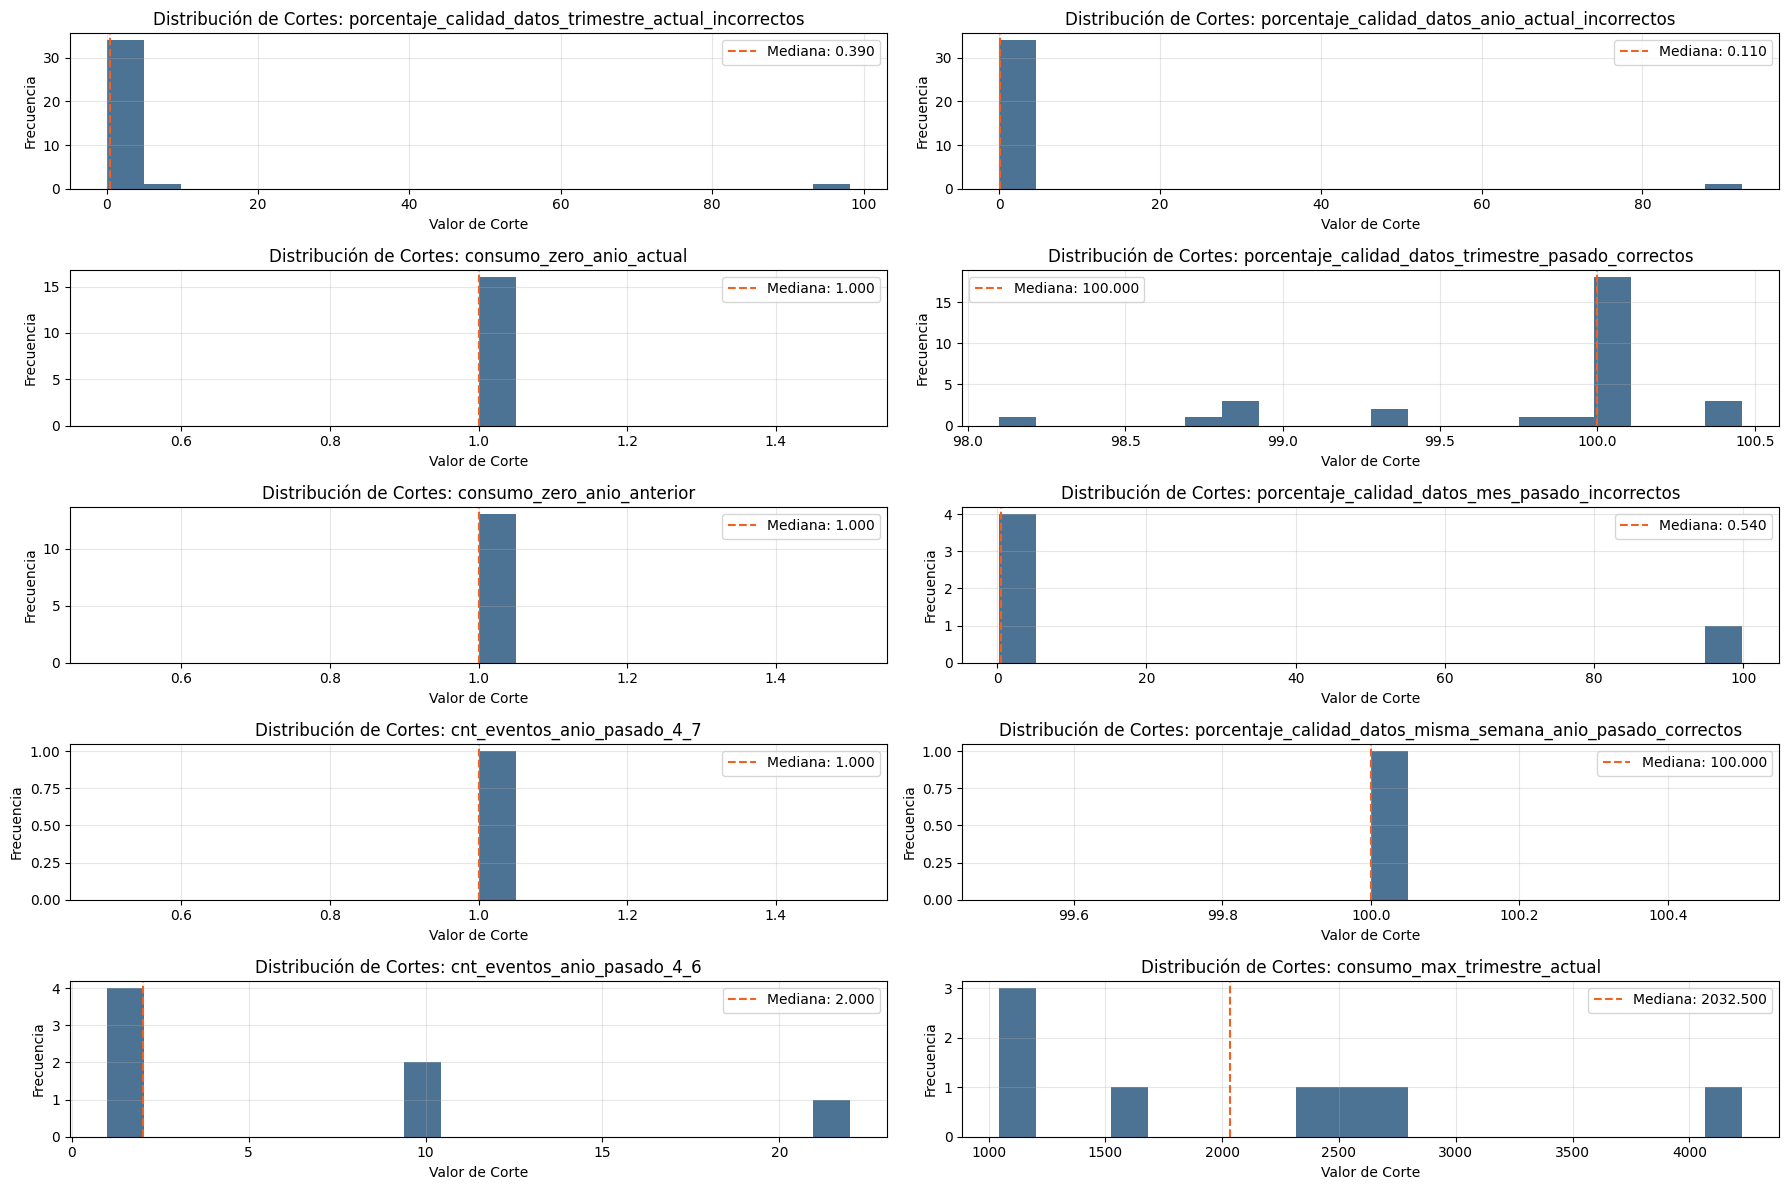

In [66]:
# Extraer información de cortes del modelo
def extract_tree_splits(model, feature_names=None):
    """
    Extrae todos los valores de corte para cada variable
    """
    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(model.n_features_in_)]
    
    # Obtener el booster
    booster = model.get_booster()
    
    # Extraer información de todos los árboles
    trees_info = []
    
    for tree_idx in range(model.n_estimators):
        try:
            tree_dump = booster.get_dump(fmap='', with_stats=True)[tree_idx]
            trees_info.append(tree_dump)
        except:
            continue
    
    # Analizar cortes por variable
    splits_by_feature = {}
    
    for tree in trees_info:
        lines = tree.split('\n')
        for line in lines:
            if '<' in line and '[' in line:
                # Extraer nombre de variable y valor de corte
                parts = line.split('[')[1].split('<')
                if len(parts) >= 2:
                    feature_name = parts[0]
                    try:
                        split_value = float(parts[1].split(']')[0])
                        if feature_name not in splits_by_feature:
                            splits_by_feature[feature_name] = []
                        splits_by_feature[feature_name].append(split_value)
                    except:
                        continue
    
    return splits_by_feature

# Ejecutar análisis
splits_info = extract_tree_splits(model, X.columns.tolist())

# Visualizar distribución de cortes para las variables más importantes
top_features = df_importancia.head(10)['feature'].tolist()

fig, axes = plt.subplots(5, 2, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    if feature in splits_info and i < 11:
        splits = splits_info[feature]
        axes[i].hist(splits, bins=20, alpha=0.7, color=ufd_blue)
        axes[i].axvline(np.median(splits), color=ufd_orange, linestyle='--', 
                       label=f'Mediana: {np.median(splits):.3f}')
        axes[i].set_title(f'Distribución de Cortes: {feature}')
        axes[i].set_xlabel('Valor de Corte')
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend()
        axes[i].grid(alpha=0.3)

# Ocultar subplots vacíos
for j in range(len(top_features), 10):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

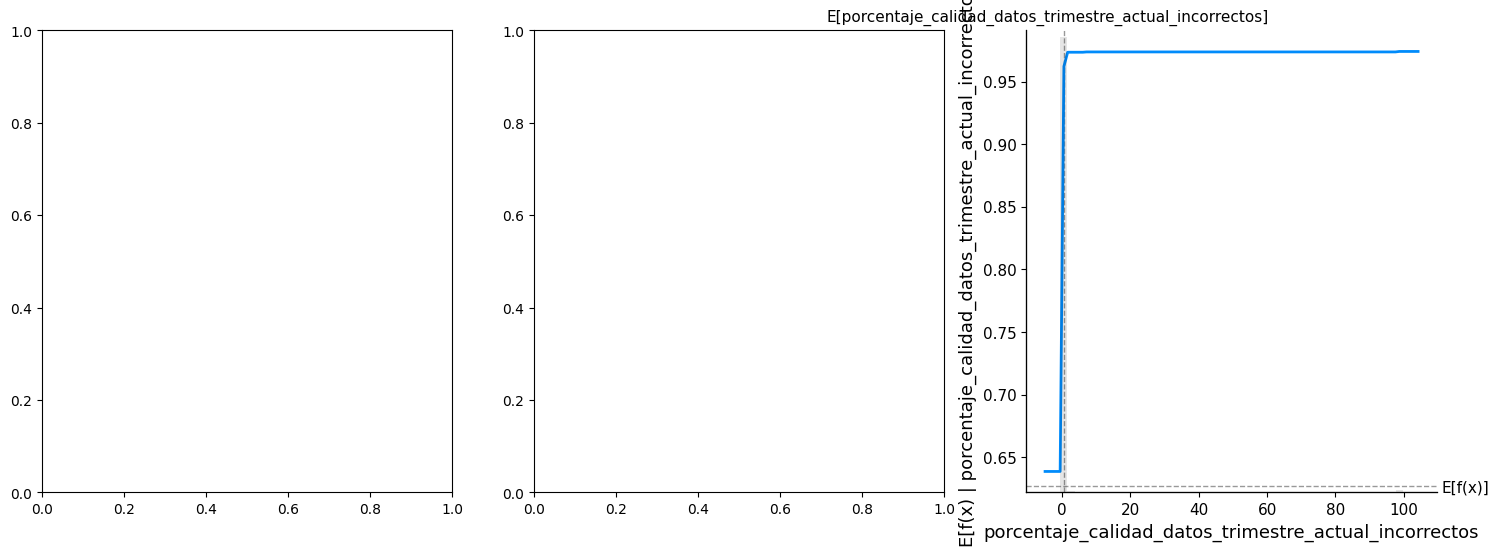

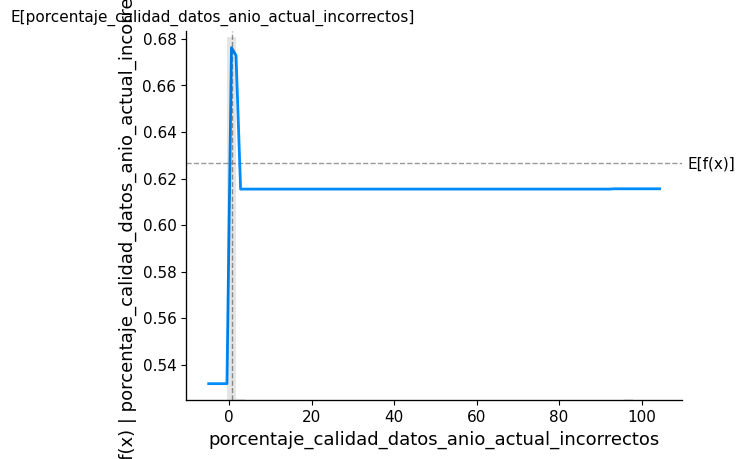

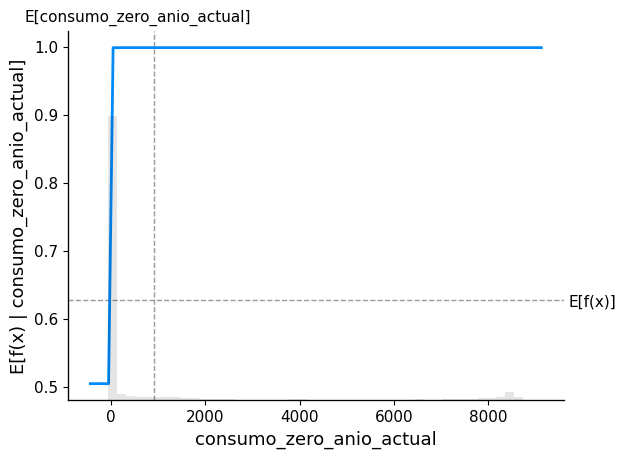

<Figure size 640x480 with 0 Axes>

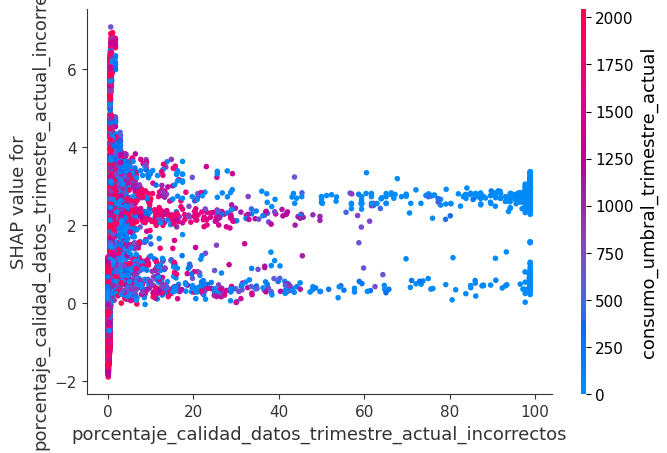

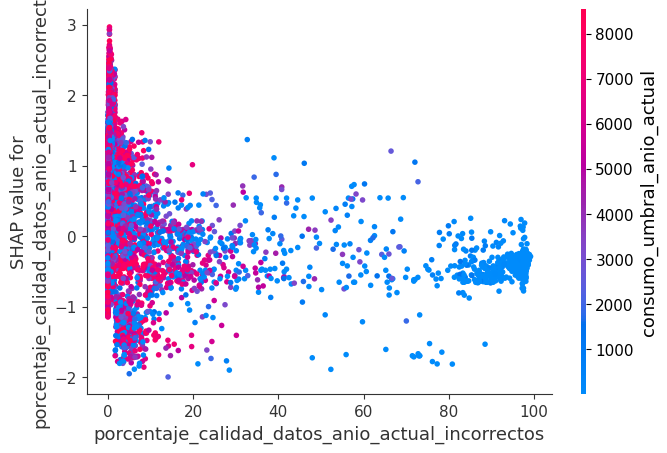

In [65]:
# Gráfico de dependencia parcial con SHAP
import shap

# Crear gráficos de dependencia para las variables más importantes
top_features = df_importancia.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(top_features):
    shap.plots.partial_dependence(
        feature, model.predict, X_eval, ice=False,
        model_expected_value=True, feature_expected_value=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Dependencia Parcial: {feature}')

plt.tight_layout()
plt.show()

# Gráfico de dependencia SHAP (muestra interacciones)
for feature in top_features[:2]:
    shap.dependence_plot(feature, shap_values, X_eval, 
                        feature_names=X_eval.columns)

In [66]:
# Crear tabla resumen de cortes
def create_splits_summary(splits_info, feature_importance_df):
    """
    Crea un resumen de los cortes más importantes
    """
    summary_data = []
    
    for feature in feature_importance_df['feature']:
        if feature in splits_info:
            splits = np.array(splits_info[feature])
            importance = feature_importance_df[
                feature_importance_df['feature'] == feature
            ]['importance'].iloc[0]
            
            summary_data.append({
                'feature': feature,
                'importance': importance,
                'num_splits': len(splits),
                'min_split': np.min(splits),
                'max_split': np.max(splits),
                'median_split': np.median(splits),
                'std_split': np.std(splits)
            })
    
    return pd.DataFrame(summary_data).sort_values('importance', ascending=False)

# Crear resumen
splits_summary = create_splits_summary(splits_info, df_importancia)
print("Resumen de Cortes por Variable (Top 10):")
print(splits_summary.head(10).round(4))

# Guardar para Power BI
splits_summary.to_csv("../powerbi/xgb_splits_summary.csv", 
                     index=False, sep=";", decimal=",")

Resumen de Cortes por Variable (Top 10):
                                             feature  importance  num_splits  \
0  porcentaje_calidad_datos_trimestre_actual_inco...      0.4089          36   
1   porcentaje_calidad_datos_anio_actual_incorrectos      0.1376          35   
2                           consumo_zero_anio_actual      0.0981          16   
3  porcentaje_calidad_datos_trimestre_pasado_corr...      0.0595          30   
4                         consumo_zero_anio_anterior      0.0500          13   
5    porcentaje_calidad_datos_mes_pasado_incorrectos      0.0272           5   
6                        cnt_eventos_anio_pasado_4_7      0.0190           1   
7  porcentaje_calidad_datos_misma_semana_anio_pas...      0.0093           1   
8                        cnt_eventos_anio_pasado_4_6      0.0088           7   
9                       consumo_max_trimestre_actual      0.0082           8   

   min_split  max_split  median_split  std_split  
0       0.05      98.21    

In [67]:
# Extraer y visualizar las reglas más importantes
def extract_important_rules(model, X_sample, top_n=10):
    """
    Extrae las reglas de decisión más comunes
    """
    # Obtener rutas de decisión para algunas muestras
    leaf_indices = model.apply(X_sample)
    
    print(f"Rutas de decisión para {len(X_sample)} muestras:")
    print(f"Forma de leaf_indices: {leaf_indices.shape}")
    print(f"Número de árboles: {model.n_estimators}")
    
    return leaf_indices

# Ejecutar con una muestra pequeña
sample_indices = np.random.choice(len(X_eval), 100, replace=False)
X_sample = X_eval.iloc[sample_indices]

leaf_info = extract_important_rules(model, X_sample)

Rutas de decisión para 100 muestras:
Forma de leaf_indices: (100, 80)
Número de árboles: 80


## 5.7. Dashboard data extraction

Necesitamos extraer ciertos ficheros para la construcción del dashboard en powerbi

In [52]:
columnas_considerar_preds = ["cups_sgc", "cnt_id", "fraude_score_no_supervisado", 
                             "pred_proba", "final_scoring", "categoria_fraude"]

In [53]:
grid_contadores_control = pd.read_csv(INPUT_GRID_CONTADORES_CONTROL_PATH_ABRIL)
grid_contadores_fraude = pd.read_csv(INPUT_GRID_CONTADORES_FRAUDE_PATH_ABRIL)

df_grid_contadores = pd.concat([grid_contadores_control, grid_contadores_fraude])

# Convertir a numérico (si hay valores raros, los pone como NaN)
df_grid_contadores["coord_utm_x_bdi"] = pd.to_numeric(df_grid_contadores["coord_utm_x_bdi"], errors="coerce")
df_grid_contadores["coord_utm_y_bdi"] = pd.to_numeric(df_grid_contadores["coord_utm_y_bdi"], errors="coerce")

# Crear transformador (UTM zona 30N -> WGS84)
transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

# Transformar coordenadas (saltará NaN si alguna fila no tenía valores válidos)
df_grid_contadores["longitud"], df_grid_contadores["latitud"] = transformer.transform(
    df_grid_contadores["coord_utm_x_bdi"].values,
    df_grid_contadores["coord_utm_y_bdi"].values
)

# df_grid_contadores.to_csv("coordenadas_contadores_lat_long.csv", index=False, decimal=",", sep=";")

NameError: name 'INPUT_GRID_CONTADORES_CONTROL_PATH_ABRIL' is not defined

In [ ]:
df_grid_contadores

,cups_sgc,cnt_id,fases_sgc,coord_utm_x_bdi,coord_utm_y_bdi,cod_postal_sgc,municipio_sgc,provincia_sgc,ccaa_sgc,longitud,latitud
0,ES0022000007510765PX1P,SOG0040091624,MONOFÁSICO,480145.0,4310079.0,13240,LA SOLANA,CIUDAD REAL,CASTILLA LA MANCHA,-3.229099,38.939421
1,ES0022000009056979YA1P,ZIV0042574489,MONOFÁSICO,447577.0,4482919.0,28055,MADRID,MADRID,MADRID,-3.618633,40.495320
2,ES0022000007875119WK1P,ZIV0048360380,MONOFÁSICO,500788.0,4710977.0,15960,RIBEIRA,A CORUÑA,GALICIA,-2.990402,42.551188
3,ES0022000007015524GM1P,ZIV0044281450,MONOFÁSICO,567463.0,4818457.0,15572,NARON,A CORUÑA,GALICIA,-2.165301,43.516003
4,ES0022000004466494JL1P,SOG0940090780,MONOFÁSICO,512077.0,4639402.0,36789,A GUARDA,PONTEVEDRA,GALICIA,-2.854387,41.906470
...,...,...,...,...,...,...,...,...,...,...,...
2313,ES0022000004089719PF1P,ZIV0035129747,MONOFÁSICO,547901.0,4800948.0,15005,A CORUÑA,A CORUÑA,GALICIA,-2.408857,43.359864
2314,ES0022000006366104NJ1P,SAG0195829801,MONOFÁSICO,447380.0,4474822.0,28037,MADRID,MADRID,MADRID,-3.620287,40.422365
2315,ES0022000005466282NC1P,ZIV0044156878,MONOFÁSICO,513456.0,4461803.0,19117,ALBALATE DE ZORITA,GUADALAJARA,CASTILLA LA MANCHA,-2.841651,40.306629
2316,ES0022000007909380CN1P,SAG0125276188,MONOFÁSICO,455480.0,4475345.0,28830,SAN FERNANDO DE HENARES,MADRID,MADRID,-3.524844,40.427549


In [ ]:
(
    final_df_eval[columnas_considerar_preds]
    .merge(df_grid_contadores, how="left", on=["cups_sgc", "cnt_id"])
    .to_csv("powerbi/predicciones_cups.csv", index=False, sep=";", decimal=",")
)

In [ ]:
def lift_at_percentile(y_true, y_proba, percentile=0.1):
    """
    Calcula el Lift en el top X% (percentile en [0,1]).
    """
    n = int(len(y_proba) * percentile)
    # Ordenar por probabilidad descendente
    idx = np.argsort(y_proba)[::-1]
    y_sorted = np.array(y_true)[idx]
    
    # Positivos en el top %
    top_positives = y_sorted[:n].sum()
    total_positives = y_sorted.sum()
    
    perc_total = top_positives / total_positives
    perc_samples = n / len(y_true)
    
    lift = perc_total / perc_samples
    return lift, perc_total

def compute_metrics(y_true, y_proba, dataset_name="test"):
    auc = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1
    ks = ks_stat(y_true, y_proba)
    lift10, capture10 = lift_at_percentile(y_true, y_proba, 0.1)
    lift20, capture20 = lift_at_percentile(y_true, y_proba, 0.2)

    return {
        "dataset": dataset_name,
        "auc": round(auc, 3),
        "gini": round(gini, 3),
        "ks": round(ks, 3),
        "lift_at_10": lift10,
        "capture_rate_10": capture10,
        "lift_at_20": lift20,
        "capture_rate_20": capture20
    }

# =====================
# Calcular métricas train y test
# =====================
metrics_train = compute_metrics(y, y_proba, dataset_name="train")
metrics_test = compute_metrics(y_eval, y_proba_eval, dataset_name="test")

model_metrics = pd.DataFrame([metrics_train, metrics_test])

model_metrics.to_csv("powerbi/model_metrics.csv", index=False, sep=";", decimal=",")

In [ ]:
model_metrics

,dataset,auc,gini,ks,lift_at_10,capture_rate_10,lift_at_20,capture_rate_20
0,train,0.997,0.994,0.960,9.835453,0.983404,4.964438,0.992888
1,test,0.917,0.833,0.718,7.696654,0.769665,4.235115,0.847023


In [ ]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba)

roc_data = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
})
roc_data.to_csv("powerbi/roc_curve.csv", index=False, sep=";", decimal=",")

ValueError: Found input variables with inconsistent numbers of samples: [36300, 34925]

In [ ]:
data = list(zip(y_eval, y_proba_eval))
data = sorted(data, key=lambda x: x[1], reverse=True)
y_sorted = np.array([d[0] for d in data])

cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

gain_data = pd.DataFrame({
    "perc_samples": perc_samples,
    "cum_gains": cum_gains
})
gain_data.to_csv("powerbi/gain_curve.csv", index=False, sep=";", decimal=",")

In [ ]:
def compute_lift(y_true, y_proba, bins=20):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift_values, percentiles = [], []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift = group_rate / total_rate
        lift_values.append(lift)
        percentiles.append(100 - (i+1)*(100//bins))  # de 100 a 0

    return pd.DataFrame({
        "percentil": percentiles,
        "lift": lift_values
    })

lift_data = compute_lift(y_test, y_proba, bins=20)
lift_data.to_csv("powerbi/lift_curve.csv", index=False, sep=";", decimal=",")